# QR 모듈 격자 피싱 분류 — Colab 실행 노트북이 노트북에는 로직을 쓰지 않는다. 전부 `qrphish` 패키지 함수 호출이고 노트북은 설정·실행·표시만 한다.셀 5 이후는 중단·재개가 가능하다 (`results.json`이 이미 있는 조합은 자동으로 건너뛴다).

산출물(`artifacts/`, `reports/`)은 학습 중 Google Drive에 직접 기록되므로 Colab 세션이 끊겨도 보존된다.

## [1] 설치

In [1]:
!pip -q install "git+https://github.com/bnbong/CNN-QR-phishing-detector.git@main"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.4/106.4 kB 9.5 MB/s eta 0:00:00


## [2] GPU 확인

In [2]:
import torch

print(torch.__version__, torch.cuda.is_available())

print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

2.11.0+cu128 True
Tesla T4


## [3] 데이터 경로 확정Drive 마운트 또는 Kaggle 다운로드 중 하나를 쓰고, 어느 쪽이든 `DATA_CSV` 변수 하나로 수렴시킨다.

In [3]:
import os

# (A) Google Drive

from google.colab import drive

drive.mount('/content/drive')

DATA_CSV = "/content/drive/MyDrive/qrphish/webphish.csv"

OUT_DIR = "/content/drive/MyDrive/qrphish_out"
os.makedirs(OUT_DIR, exist_ok=True)

Mounted at /content/drive


In [4]:
# (B) Kaggle — kaggle.json 업로드 후
# from google.colab import files; files.upload()
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d guchiopara/look-before-you-leap -p /content/data --unzip# DATA_CSV = "/content/data/<파일명>.csv"
# OUT_DIR = "/content/drive/MyDrive/qrphish_out"  # Drive 마운트 시와 동일하게 정의 필요

## [4] config 로드

In [5]:
!git clone -q https://github.com/bnbong/CNN-QR-phishing-detector.git /content/repo
%cd /content/repo

from qrphish.config import load_config
from qrphish.runner import apply_overrides

# Config는 frozen dataclass다. 필드를 직접 대입하지 말고 점 표기 오버라이드를 쓴다.
cfg = apply_overrides(
    load_config("configs/base.yaml"),
    {
        "data.csv_path": DATA_CSV,
        "output_dir": OUT_DIR + "/artifacts",
        "reports_dir": OUT_DIR + "/reports",
    },
)
cfg

/content/repo


Config(seed_list=(0, 1, 2, 3, 4), data=DataConfig(csv_path='/content/drive/MyDrive/qrphish/webphish.csv', category_col='Category', url_col='Data', positive_label='spam'), qr=QRConfig(ec='L', optimize=0, border=0, mask_mode='fixed', mask_pattern=0, pad_mode='spec'), condition=ConditionConfig(url_mode='norm', length_match='exact', length_bucket=1, features='data_only', path_filter=False, shuffle_positions=False), strata=('v2', 'v3', 'v4', 'v5plus'), stratum_rules=StratumRules(primary_min_per_class=1000, secondary_min_per_class=300), split=SplitConfig(ratios=(0.7, 0.15, 0.15), max_group_frac=0.05), model=ModelConfig(arch='small_cnn', lr=0.001, weight_decay=0.0001, batch_size=256, max_epochs=60, patience=8, class_weight='balanced', amp=True), eval=EvalConfig(n_bootstrap=2000, primary_metric='auroc'), output_dir='/content/drive/MyDrive/qrphish_out/artifacts', reports_dir='/content/drive/MyDrive/qrphish_out/reports')

## [5] P0 — 모델 학습 전에 반드시 통과시킨다층 카운트 표, `first_pad_codeword` 클래스별 분포, 그룹 분할 진단, 라운드트립 게이트.**여기서 어떤 층이 primary인지 눈으로 확인하고 진행 여부를 결정한다.**

In [6]:
from qrphish.runner import run_p0

p0 = run_p0(cfg)


print("roundtrip gate:", p0["roundtrip_gate"]["passed"], p0["roundtrip_gate"]["n_checked"])

import pandas as pd

pd.DataFrame(p0["stratum_counts"]["cells"])

roundtrip gate: True 1584


,length_match,stratum,n_total,n_by_class,per_class_min,tier,n_in_stratum_before_match
0,exact,v2,12118,"{'1': 6059, '0': 6059}",6059,primary,18718
1,exact,v3,9178,"{'1': 4589, '0': 4589}",4589,primary,11996
2,exact,v4,2714,"{'1': 1357, '0': 1357}",1357,primary,3930
3,exact,v5plus,532,"{'1': 266, '0': 266}",266,dropped,4147
4,quantile,v2,12200,"{'1': 6100, '0': 6100}",6100,primary,18718
5,quantile,v3,9230,"{'1': 4615, '0': 4615}",4615,primary,11996
6,quantile,v4,2802,"{'1': 1401, '0': 1401}",1401,primary,3930
7,quantile,v5plus,544,"{'1': 272, '0': 272}",272,dropped,4147
8,none,v2,16627,"{'0': 10489, '1': 6138}",6138,primary,18718
9,none,v3,11996,"{'0': 7350, '1': 4646}",4646,primary,11996


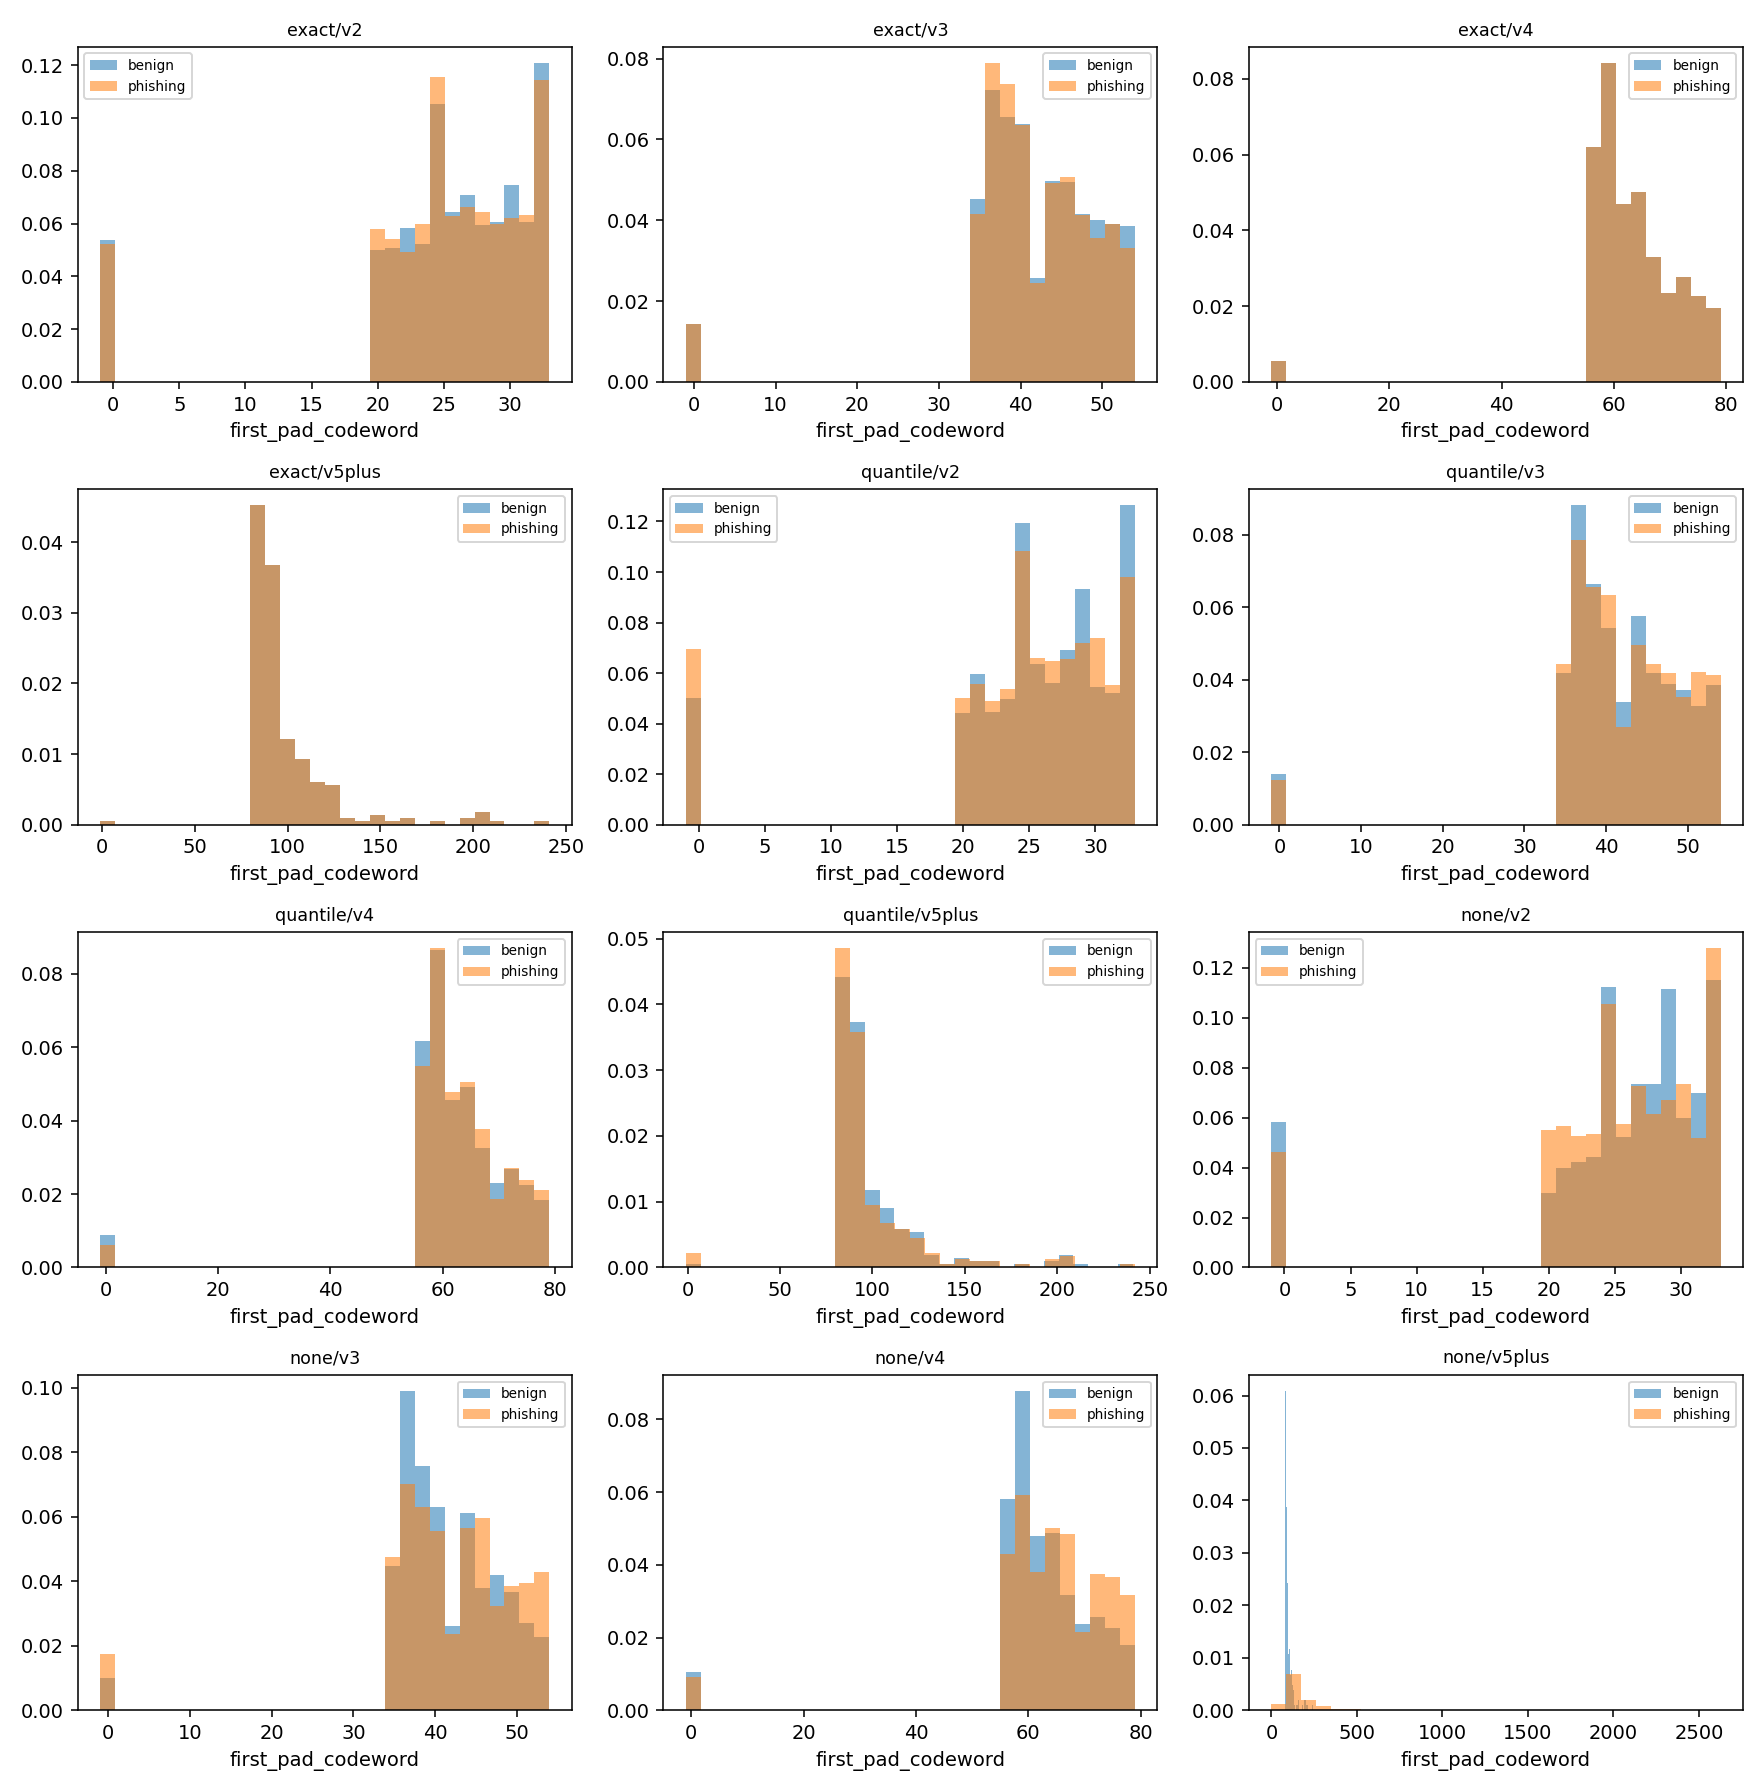

In [7]:
from IPython.display import Image

Image(p0["first_pad_png"])

## [6] P1 — 주 실험

In [8]:
from qrphish.runner import run_matrix

_ = run_matrix(cfg, "P1")

[run ] P1 norm-exact-data_only-fixed-small_cnn/v2
[run ] P1 norm-exact-data_only-fixed-small_cnn/v3
[run ] P1 norm-exact-data_only-fixed-small_cnn/v4
[run ] P1 norm-exact-data_only-fixed-bit_mlp/v2
[run ] P1 norm-exact-data_only-fixed-bit_mlp/v3
[run ] P1 norm-exact-data_only-fixed-bit_mlp/v4
[run ] P1 norm-exact-data_only-fixed-small_cnn-shufflepos/v2
[run ] P1 norm-exact-data_only-fixed-small_cnn-shufflepos/v3
[run ] P1 norm-exact-data_only-fixed-small_cnn-shufflepos/v4
[run ] P1 norm-exact-data_only-fixed-bit_mlp-shufflepos/v2
[run ] P1 norm-exact-data_only-fixed-bit_mlp-shufflepos/v3
[run ] P1 norm-exact-data_only-fixed-bit_mlp-shufflepos/v4
[run ] P1 norm-exact-data_only-fixed-small_cnn-labelshuffle/v2
[run ] P1 norm-exact-data_only-fixed-small_cnn-labelshuffle/v3
[run ] P1 norm-exact-data_only-fixed-small_cnn-labelshuffle/v4


## [7] P2 — 절제

In [9]:
_ = run_matrix(cfg, "P2")

[run ] P2 norm-none-data_only-fixed-small_cnn/v2
[run ] P2 norm-none-data_only-fixed-small_cnn/v3
[run ] P2 norm-none-data_only-fixed-small_cnn/v4
[run ] P2 norm-quantile-data_only-fixed-small_cnn/v2
[run ] P2 norm-quantile-data_only-fixed-small_cnn/v3
[run ] P2 norm-quantile-data_only-fixed-small_cnn/v4
[run ] P2 raw-exact-data_only-fixed-small_cnn/v2
[run ] P2 raw-exact-data_only-fixed-small_cnn/v3
[run ] P2 raw-exact-data_only-fixed-small_cnn/v4
[run ] P2 norm-exact-all-fixed-small_cnn/v2
[run ] P2 norm-exact-all-fixed-small_cnn/v3
[run ] P2 norm-exact-all-fixed-small_cnn/v4
[run ] P2 norm-exact-data_only-auto-small_cnn/v2
[run ] P2 norm-exact-data_only-auto-small_cnn/v3
[run ] P2 norm-exact-data_only-auto-small_cnn/v4
[run ] P2 norm-exact-data_only-off-small_cnn/v2
[run ] P2 norm-exact-data_only-off-small_cnn/v3
[run ] P2 norm-exact-data_only-off-small_cnn/v4
[run ] P2 norm-none-data_only-fixed-small_cnn-padrand/v2
[run ] P2 norm-none-data_only-fixed-small_cnn-padrand/v3
[run ] P2 

## [8] P3 — 해석 (Grad-CAM)

In [10]:
from qrphish.runner import run_explain, condition_id

best_condition = "norm-exact-data_only-off-small_cnn"   # mask-off 최고 성능 조건
explain_result = run_explain(cfg, best_condition)
explain_result

{'v2': {'n_samples': 128,
  'cam_mass_by_kind': {'function': 0.3382859164484264,
   'char': 0.3855102426154049,
   'length_header': 0.015046347670259658,
   'mode_header': 0.007738427578285722,
   'pad': 0.09405255564494228,
   'ec': 0.13654349284687564,
   'remainder': 0.007198017195805477},
  'char_position_curve': {'0': [0.09284109817665406,
    0.10455758322473872,
    0.11389462824648246,
    0.12082456010710424,
    0.12760138382682948,
    0.12603980596248887,
    0.11679297141156425,
    0.10745521798007461,
    0.10836236848132565,
    0.1127772174558053,
    0.11914246242587226,
    0.11546266159502465,
    0.11006190282180031,
    0.1055021358433463,
    0.10701829279531742,
    0.10428408753063752,
    0.10630075902871662,
    0.10599937747883184,
    0.11055823140599753,
    0.12896752358541283,
    0.13654243666099386,
    0.1368732041724899,
    0.1354946696989452,
    0.13119231217571362,
    0.13766779814250993,
    0.14416476115505836,
    0.14690588980625421,
    0.1

## [9] 결과 저장 + 표 미리보기

In [11]:
from qrphish.runner import aggregate_reports

tables = aggregate_reports(cfg)
tables

{'main': PosixPath('/content/drive/MyDrive/qrphish_out/reports/table_main.csv'),
 'baselines': PosixPath('/content/drive/MyDrive/qrphish_out/reports/table_baselines.csv'),
 'P1': PosixPath('/content/drive/MyDrive/qrphish_out/reports/table_p1.csv'),
 'P2': PosixPath('/content/drive/MyDrive/qrphish_out/reports/table_p2.csv')}

In [12]:
import pandas as pd

pd.read_csv(tables["main"])

,condition_id,phase,stratum,tier,n_total,auroc_mean,auroc_sd,auroc_ci_lo,auroc_ci_hi,f1_mean,acc_mean,text_upper_bound_auroc,below_text_upper_bound
0,norm-exact-all-fixed-small_cnn,P2,v2,primary,12118,0.872618,0.022091,0.834160,0.905205,0.790971,0.782946,0.968901,True
1,norm-exact-all-fixed-small_cnn,P2,v3,primary,9178,0.802104,0.033247,0.742588,0.856699,0.730330,0.709791,0.971886,True
2,norm-exact-all-fixed-small_cnn,P2,v4,primary,2714,0.812811,0.011848,0.753391,0.866031,0.742374,0.727395,0.991961,True
3,norm-exact-data_only-auto-small_cnn,P2,v2,primary,12118,0.748038,0.023212,0.709302,0.785184,0.707052,0.657643,0.968901,True
4,norm-exact-data_only-auto-small_cnn,P2,v3,primary,9178,0.678153,0.025991,0.634396,0.721897,0.672634,0.568869,0.971886,True
5,norm-exact-data_only-auto-small_cnn,P2,v4,primary,2714,0.674639,0.039088,0.614986,0.732724,0.656953,0.579174,0.991961,True
6,norm-exact-data_only-fixed-bit_mlp,P1,v2,primary,12118,0.833541,0.018244,0.786474,0.875748,0.759562,0.735009,0.968901,True
7,norm-exact-data_only-fixed-bit_mlp,P1,v3,primary,9178,0.731848,0.026017,0.671942,0.791319,0.683957,0.629418,0.971886,True
8,norm-exact-data_only-fixed-bit_mlp,P1,v4,primary,2714,0.690029,0.017611,0.615078,0.757004,0.655377,0.599894,0.991961,True
9,norm-exact-data_only-fixed-bit_mlp-shufflepos,P1,v2,primary,12118,0.833930,0.020812,0.787065,0.875965,0.758779,0.736080,NaN,True


산출물은 학습 중 Drive에 직접 기록되므로 세션이 끊겨도 보존되며, 재실행 시 results.json이 있는 조건은 건너뛴다.

In [13]:
!ls -la $OUT_DIR/reports
!du -sh $OUT_DIR/artifacts

total 188
-rw------- 1 root root 149963 Sep  6 13:21 first_pad_codeword.png
-rw------- 1 root root     78 Sep  6 13:21 roundtrip_gate.json
-rw------- 1 root root  15139 Sep  6 13:21 split_diagnostics.json
-rw------- 1 root root   3206 Sep  6 13:21 stratum_counts.json
-rw------- 1 root root   5697 Sep  6 15:33 table_baselines.csv
-rw------- 1 root root   7921 Sep  6 15:33 table_main.csv
-rw------- 1 root root   3010 Sep  6 15:33 table_p1.csv
-rw------- 1 root root   5058 Sep  6 15:33 table_p2.csv
341M	/content/drive/MyDrive/qrphish_out/artifacts
